In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot')

In [2]:
nav_df = pd.read_csv('../data/processed/02_nav_history_clean.csv')

print(nav_df.shape)
print(nav_df.columns)

nav_df.head()

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)

nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [4]:
nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [5]:
print(nav_df['daily_return'].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [6]:
nav_df['daily_return'].isnull().sum()

np.int64(40)

In [7]:
nav_returns = nav_df.dropna(subset=['daily_return'])

print(nav_returns.shape)

(45960, 4)


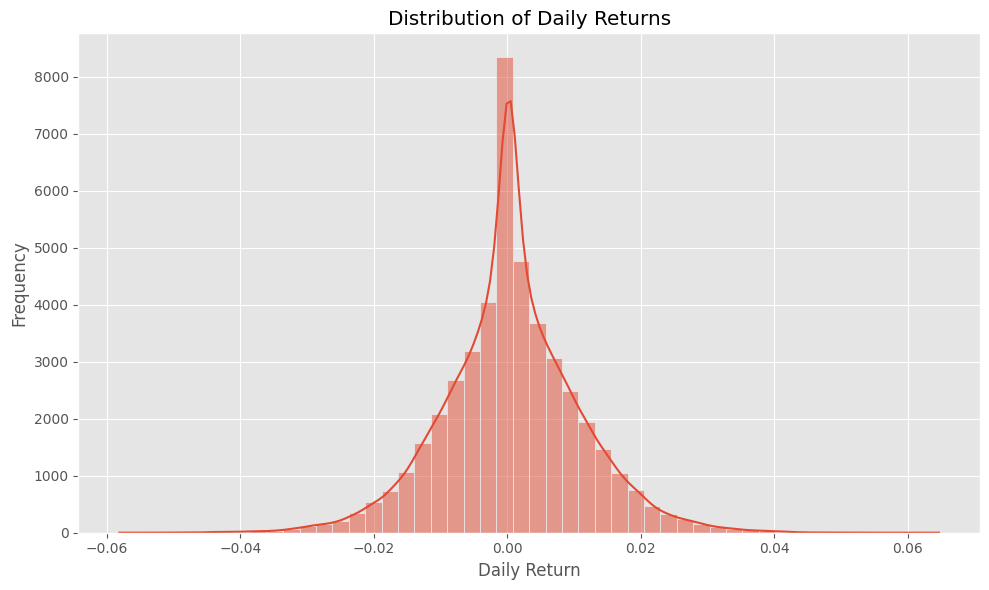

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_returns['daily_return'],
    bins=50,
    kde=True
)

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    '../report/daily_return_distribution.png',
    bbox_inches='tight'
)

plt.show()

### Insight 1: Daily Return Distribution

The distribution of daily returns is centered close to zero and resembles a normal distribution with slight tails. Most daily returns fall within a narrow range, indicating stable day-to-day movement, while extreme positive and negative returns occur infrequently.

In [9]:
print(nav_df['date'].min())
print(nav_df['date'].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [10]:
nav_df['amfi_code'].nunique()

40

In [11]:
def calculate_cagr(nav_data, years):
    
    end_date = nav_data['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    period_data = nav_data[
        nav_data['date'] >= start_date
    ]
    
    if len(period_data) < 2:
        return np.nan
    
    start_nav = period_data.iloc[0]['nav']
    end_nav = period_data.iloc[-1]['nav']
    
    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100
    
    return cagr

In [12]:
cagr_results = []

for fund in nav_df['amfi_code'].unique():
    
    fund_data = nav_df[
        nav_df['amfi_code'] == fund
    ].sort_values('date')
    
    cagr_1y = calculate_cagr(fund_data, 1)
    cagr_3y = calculate_cagr(fund_data, 3)
    
    cagr_results.append({
        'amfi_code': fund,
        'CAGR_1Y': cagr_1y,
        'CAGR_3Y': cagr_3y
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y
0,100016,-2.224271,1.292649
1,100025,3.704969,3.916390
2,100033,53.232396,32.442459
3,101206,47.924120,28.967695
4,101207,-23.986032,-4.152381


In [13]:
cagr_df.describe()

,amfi_code,CAGR_1Y,CAGR_3Y
count,40.000000,40.000000,40.000000
mean,120247.000000,19.428520,16.414715
std,14534.998667,22.912276,12.206752
min,100016.000000,-42.797615,-11.705807
25%,118632.750000,7.377949,6.600925
50%,119551.500000,17.474125,18.233102
75%,120842.250000,27.161651,26.902600
max,149324.000000,82.776059,35.111802


In [14]:
cagr_df = cagr_df.sort_values(
    'CAGR_3Y',
    ascending=False
)

cagr_df['CAGR_3Y_Rank'] = range(
    1,
    len(cagr_df) + 1
)

cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_3Y_Rank
16,119094,22.261065,35.111802,1
34,148567,20.360678,34.000916,2
24,120504,13.064279,32.487429,3
2,100033,53.232396,32.442459,4
25,120505,29.604659,31.777537,5
19,119551,60.437341,30.456524,6
30,120843,26.657082,29.582770,7
36,148569,39.751761,29.178902,8
3,101206,47.924120,28.967695,9
39,149324,65.138719,27.000427,10


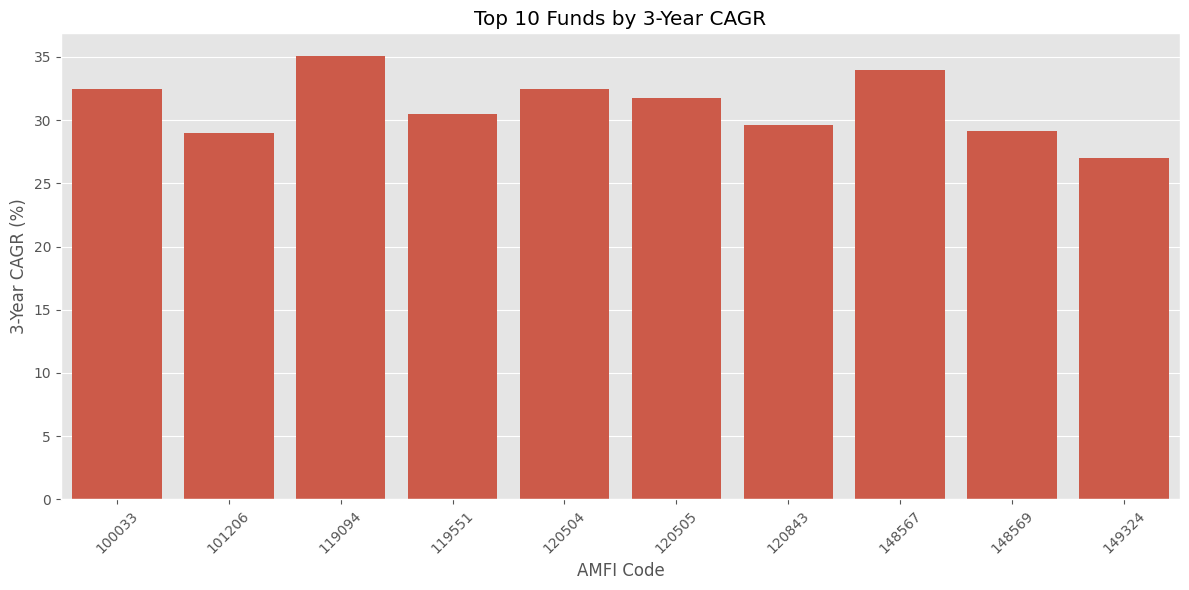

In [15]:
top10 = cagr_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='amfi_code',
    y='CAGR_3Y'
)

plt.title('Top 10 Funds by 3-Year CAGR')
plt.xlabel('AMFI Code')
plt.ylabel('3-Year CAGR (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../report/top10_cagr_3y.png',
    bbox_inches='tight'
)

plt.show()

In [16]:
cagr_df.to_csv(
    '../report/cagr_comparison.csv',
    index=False
)

### Insight 2: CAGR Performance Comparison

The top-performing funds generated significantly higher 3-year CAGR compared to the median fund. While several schemes delivered annualized returns above 25%, a few funds experienced negative growth, highlighting the dispersion in long-term fund performance.

In [17]:
risk_free_rate = 0.065

In [18]:
sharpe_results = []

for fund in nav_returns['amfi_code'].unique():

    fund_returns = nav_returns[
        nav_returns['amfi_code'] == fund
    ]['daily_return']

    annual_return = fund_returns.mean() * 252

    annual_volatility = (
        fund_returns.std() * np.sqrt(252)
    )

    sharpe_ratio = (
        (annual_return - risk_free_rate)
        / annual_volatility
    )

    sharpe_results.append({
        'amfi_code': fund,
        'Sharpe_Ratio': sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [19]:
sharpe_df.describe()

,amfi_code,Sharpe_Ratio
count,40.000000,40.000000
mean,120247.000000,0.537220
std,14534.998667,0.573689
min,100016.000000,-0.815567
25%,118632.750000,0.064696
50%,119551.500000,0.647043
75%,120842.250000,1.005304
max,149324.000000,1.448291


In [20]:
sharpe_df = sharpe_df.sort_values(
    'Sharpe_Ratio',
    ascending=False
)

sharpe_df['Sharpe_Rank'] = range(
    1,
    len(sharpe_df) + 1
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1
30,120843,1.306744,2
36,148569,1.234930,3
19,119551,1.208267,4
25,120505,1.180101,5
38,149323,1.132122,6
2,100033,1.093699,7
9,118632,1.081659,8
3,101206,1.027213,9
24,120504,1.026524,10


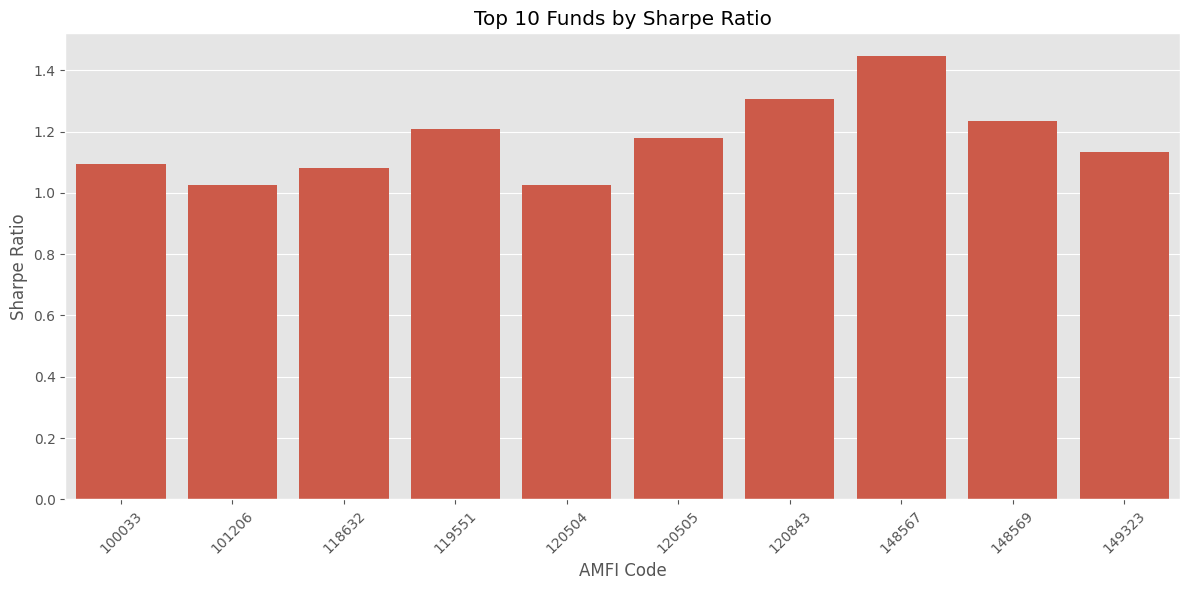

In [21]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x='amfi_code',
    y='Sharpe_Ratio'
)

plt.title('Top 10 Funds by Sharpe Ratio')
plt.xlabel('AMFI Code')
plt.ylabel('Sharpe Ratio')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../report/top10_sharpe_ratio.png',
    bbox_inches='tight'
)

plt.show()

In [22]:
sharpe_df.to_csv(
    '../report/sharpe_ratio.csv',
    index=False
)

### Insight 3: Sharpe Ratio Comparison

Funds with higher Sharpe ratios generated better risk-adjusted returns, delivering superior performance for each unit of risk taken. The top-ranked funds achieved Sharpe ratios above 1.0, indicating efficient return generation relative to volatility.

In [23]:
sortino_results = []

for fund in nav_returns['amfi_code'].unique():

    fund_returns = nav_returns[
        nav_returns['amfi_code'] == fund
    ]['daily_return']

    annual_return = fund_returns.mean() * 252

    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = (
        downside_returns.std() * np.sqrt(252)
    )

    sortino_ratio = (
        (annual_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append({
        'amfi_code': fund,
        'Sortino_Ratio': sortino_ratio
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [24]:
sortino_df.describe()

,amfi_code,Sortino_Ratio
count,40.000000,40.000000
mean,120247.000000,0.923338
std,14534.998667,1.005410
min,100016.000000,-1.681038
25%,118632.750000,0.106664
50%,119551.500000,1.116936
75%,120842.250000,1.727739
max,149324.000000,2.385644


In [25]:
sortino_df = sortino_df.sort_values(
    'Sortino_Ratio',
    ascending=False
)

sortino_df['Sortino_Rank'] = range(
    1,
    len(sortino_df) + 1
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.385644,1
30,120843,2.364320,2
36,148569,2.146914,3
19,119551,2.140267,4
25,120505,2.029353,5
38,149323,1.875101,6
9,118632,1.850133,7
2,100033,1.829134,8
24,120504,1.805294,9
3,101206,1.799563,10


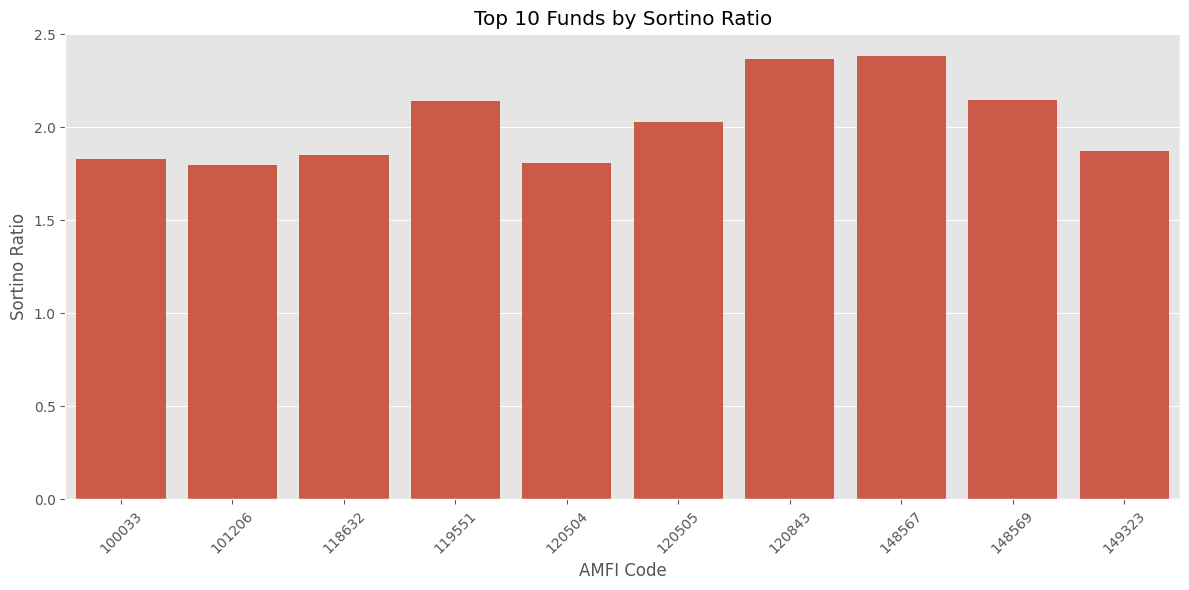

In [26]:
top10_sortino = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x='amfi_code',
    y='Sortino_Ratio'
)

plt.title('Top 10 Funds by Sortino Ratio')
plt.xlabel('AMFI Code')
plt.ylabel('Sortino Ratio')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../report/top10_sortino_ratio.png',
    bbox_inches='tight'
)

plt.show()

In [27]:
sortino_df.to_csv(
    '../report/sortino_ratio.csv',
    index=False
)

### Insight 4: Sortino Ratio Comparison

The highest-ranked funds achieved superior returns while limiting downside volatility. Compared to Sharpe Ratio, the Sortino Ratio provides a more focused assessment of downside risk, highlighting funds that effectively protected investor capital during market declines.

In [28]:
benchmark_df = pd.read_csv('../data/raw/10_benchmark_indices.csv')

print(benchmark_df.shape)
print(benchmark_df.columns)

benchmark_df.head()

(8050, 3)
Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [29]:
benchmark_df['index_name'].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [30]:
nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [31]:
nifty100 = nifty100.dropna(
    subset=['benchmark_return']
)

print(nifty100.shape)

(1149, 4)


In [32]:
print(
    nifty100['benchmark_return']
    .describe()
)

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


In [33]:
merged_df = pd.merge(
    nav_returns,
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

print(merged_df.shape)

merged_df.head()

(45960, 5)


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [34]:
print(merged_df.columns)

merged_df[['daily_return',
           'benchmark_return']].head()

Index(['amfi_code', 'date', 'nav', 'daily_return', 'benchmark_return'], dtype='str')


,daily_return,benchmark_return
0,-0.010306,-0.013540
1,0.012865,0.004003
2,-0.011377,-0.002935
3,-0.001210,0.006150
4,-0.008639,-0.008351


In [35]:
from scipy.stats import linregress

In [36]:
alpha_beta_results = []

for fund in merged_df['amfi_code'].unique():

    fund_data = merged_df[
        merged_df['amfi_code'] == fund
    ]

    beta, alpha, r_value, p_value, std_err = linregress(
        fund_data['benchmark_return'],
        fund_data['daily_return']
    )

    alpha_beta_results.append({
        'amfi_code': fund,
        'Alpha': alpha * 252,
        'Beta': beta,
        'R_Squared': r_value ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [37]:
alpha_beta_df.describe()

,amfi_code,Alpha,Beta,R_Squared
count,40.000000,40.000000,40.000000,4.000000e+01
mean,120247.000000,0.159085,-0.001958,6.087700e-04
std,14534.998667,0.087528,0.035194,7.265363e-04
min,100016.000000,0.028969,-0.066951,1.345534e-07
25%,118632.750000,0.068612,-0.023937,5.495723e-05
50%,119551.500000,0.162326,-0.000067,3.455513e-04
75%,120842.250000,0.221723,0.017026,1.035467e-03
max,149324.000000,0.303370,0.103497,2.793007e-03


In [38]:
merged_df[['daily_return', 'benchmark_return']].corr()

,daily_return,benchmark_return
daily_return,1.000000,-0.001545
benchmark_return,-0.001545,1.000000


In [39]:
merged_df[['daily_return', 'benchmark_return']].describe()

,daily_return,benchmark_return
count,45960.000000,45960.000000
mean,0.000631,0.000122
std,0.010290,0.008116
min,-0.058102,-0.026873
25%,-0.005042,-0.005385
50%,0.000340,-0.000112
75%,0.006324,0.005456
max,0.064713,0.026795


In [40]:
test_fund = merged_df[
    merged_df['amfi_code'] == 100033
]

print(
    test_fund[['daily_return',
               'benchmark_return']]
    .corr()
)

                  daily_return  benchmark_return
daily_return          1.000000          0.003474
benchmark_return      0.003474          1.000000


In [41]:
merged_df['amfi_code'].value_counts().head()

amfi_code
100016    1149
100025    1149
100033    1149
101206    1149
101207    1149
Name: count, dtype: int64

In [42]:
alpha_beta_df = alpha_beta_df.sort_values(
    'Alpha',
    ascending=False
)

alpha_beta_df.to_csv(
    '../report/alpha_beta.csv',
    index=False
)

alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,R_Squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


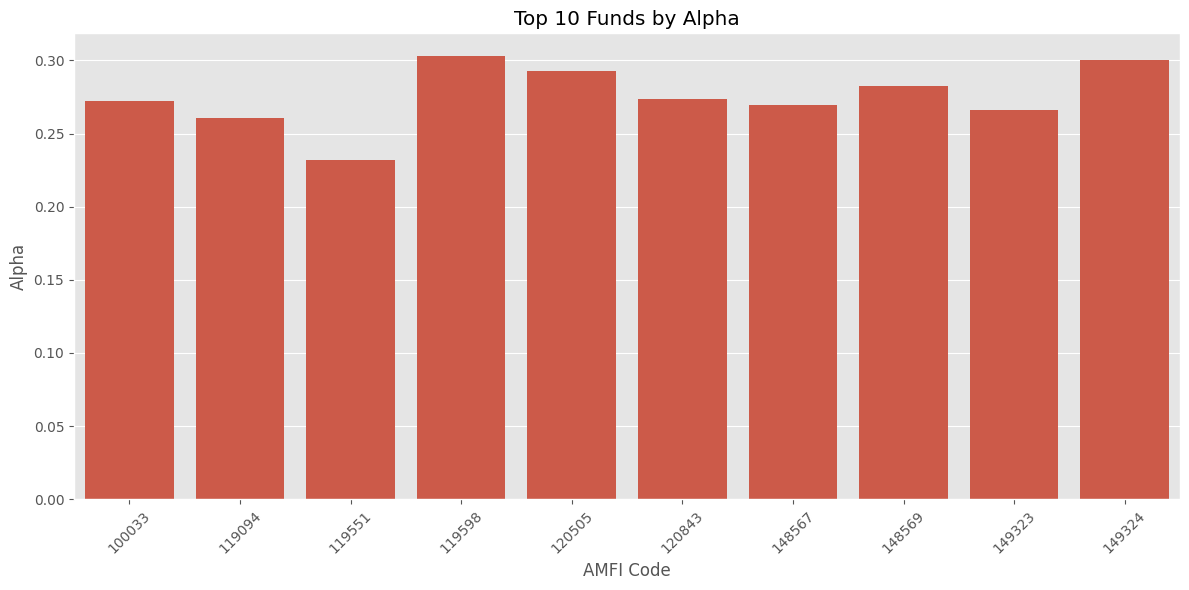

In [43]:
top10_alpha = alpha_beta_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_alpha,
    x='amfi_code',
    y='Alpha'
)

plt.title('Top 10 Funds by Alpha')
plt.xlabel('AMFI Code')
plt.ylabel('Alpha')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../report/top10_alpha.png',
    bbox_inches='tight'
)

plt.show()

### Insight 5: Alpha and Beta Analysis

Alpha measures excess returns generated beyond benchmark expectations, while Beta measures sensitivity to market movements. Funds with higher Alpha values outperformed the benchmark on a risk-adjusted basis, whereas Beta values indicate the degree of market exposure.

In [44]:
drawdown_results = []

for fund in nav_df['amfi_code'].unique():

    fund_data = nav_df[
        nav_df['amfi_code'] == fund
    ].sort_values('date')

    running_max = fund_data['nav'].cummax()

    drawdown = (
        fund_data['nav'] /
        running_max - 1
    )

    max_drawdown = drawdown.min()

    drawdown_results.append({
        'amfi_code': fund,
        'Max_Drawdown': max_drawdown * 100
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


In [45]:
drawdown_df.sort_values(
    'Max_Drawdown',
    ascending=False
).head(10)


,amfi_code,Max_Drawdown
27,120507,-0.097731
31,120844,-0.116293
5,101208,-0.162250
1,100025,-4.308264
18,119120,-4.328729
13,118636,-8.316362
6,102885,-10.859862
34,148567,-11.265729
3,101206,-11.291596
12,118635,-11.650625


In [46]:
drawdown_df.sort_values(
    'Max_Drawdown'
).head(10)

,amfi_code,Max_Drawdown
22,119599,-52.574221
17,119095,-51.677754
4,101207,-35.446916
39,149324,-31.171900
21,119598,-28.706006
7,102886,-28.001124
0,100016,-24.734441
29,120842,-24.003511
11,118634,-23.344886
15,119093,-21.751396


In [48]:
drawdown_df.to_csv(
    "../report/max_drawdown.csv",
    index=False
)

In [51]:
print("cagr_df:", 'cagr_df' in globals())
print("sharpe_df:", 'sharpe_df' in globals())
print("volatility_df:", 'volatility_df' in globals())
print("alpha_beta_df:", 'alpha_beta_df' in globals())
print("drawdown_df:", 'drawdown_df' in globals())

cagr_df: True
sharpe_df: True
volatility_df: False
alpha_beta_df: True
drawdown_df: True


In [52]:
[var for var in globals() if 'vol' in var.lower()]

['annual_volatility']

In [54]:
print('nav_df' in globals())

True


In [55]:
daily_returns = (
    nav_df
    .sort_values(['amfi_code', 'date'])
    .groupby('amfi_code')['nav']
    .pct_change()
)

volatility_df = (
    pd.DataFrame({
        'amfi_code': nav_df['amfi_code'],
        'daily_return': daily_returns
    })
    .groupby('amfi_code')['daily_return']
    .std()
    .reset_index()
)

volatility_df['Volatility'] = volatility_df['daily_return'] * (252 ** 0.5) * 100

volatility_df = volatility_df[['amfi_code', 'Volatility']]

volatility_df.head()

,amfi_code,Volatility
0,100016,14.548135
1,100025,3.905246
2,100033,18.936711
3,101206,14.568213
4,101207,25.797322


In [56]:
scorecard_df = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
).merge(
    volatility_df,
    on='amfi_code'
).merge(
    alpha_beta_df,
    on='amfi_code'
).merge(
    drawdown_df,
    on='amfi_code'
)

scorecard_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_3Y_Rank,Sharpe_Ratio,Sharpe_Rank,Volatility,Alpha,Beta,R_Squared,Max_Drawdown
0,119094,22.261065,35.111802,1,0.998231,11,19.407117,0.260767,-0.066265,1.936879e-03,-20.960884
1,148567,20.360678,34.000916,2,1.448291,1,14.193707,0.269838,0.023684,4.625437e-04,-11.265729
2,120504,13.064279,32.487429,3,1.026524,10,14.363781,0.211948,0.016232,2.121613e-04,-12.588276
3,100033,53.232396,32.442459,4,1.093699,7,18.936711,0.271954,0.005104,1.206652e-05,-16.217209
4,120505,29.604659,31.777537,5,1.180101,5,19.290949,0.292636,0.000549,1.345534e-07,-18.188514


In [57]:
scorecard_df = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
).merge(
    volatility_df,
    on='amfi_code'
).merge(
    alpha_beta_df,
    on='amfi_code'
).merge(
    drawdown_df,
    on='amfi_code'
)

scorecard_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_3Y_Rank,Sharpe_Ratio,Sharpe_Rank,Volatility,Alpha,Beta,R_Squared,Max_Drawdown
0,119094,22.261065,35.111802,1,0.998231,11,19.407117,0.260767,-0.066265,1.936879e-03,-20.960884
1,148567,20.360678,34.000916,2,1.448291,1,14.193707,0.269838,0.023684,4.625437e-04,-11.265729
2,120504,13.064279,32.487429,3,1.026524,10,14.363781,0.211948,0.016232,2.121613e-04,-12.588276
3,100033,53.232396,32.442459,4,1.093699,7,18.936711,0.271954,0.005104,1.206652e-05,-16.217209
4,120505,29.604659,31.777537,5,1.180101,5,19.290949,0.292636,0.000549,1.345534e-07,-18.188514


In [58]:
scorecard_df.columns.tolist()

['amfi_code',
 'CAGR_1Y',
 'CAGR_3Y',
 'CAGR_3Y_Rank',
 'Sharpe_Ratio',
 'Sharpe_Rank',
 'Volatility',
 'Alpha',
 'Beta',
 'R_Squared',
 'Max_Drawdown']

In [60]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

In [61]:
scorecard_df['CAGR_Score'] = minmax(scorecard_df['CAGR_3Y'])

scorecard_df['Sharpe_Score'] = minmax(scorecard_df['Sharpe_Ratio'])

scorecard_df['Alpha_Score'] = minmax(scorecard_df['Alpha'])

In [62]:
scorecard_df['Volatility_Score'] = 1 - minmax(
    scorecard_df['Volatility']
)

scorecard_df['Drawdown_Score'] = 1 - minmax(
    scorecard_df['Max_Drawdown']
)

In [63]:
scorecard_df['Beta_Score'] = 1 - abs(
    scorecard_df['Beta'] - 1
)

scorecard_df['Beta_Score'] = minmax(
    scorecard_df['Beta_Score']
)

In [67]:
scorecard_df['Fund_Score'] = (
    scorecard_df['CAGR_Score'] * 0.25 +
    scorecard_df['Sharpe_Score'] * 0.25 +
    scorecard_df['Alpha_Score'] * 0.15 +
    scorecard_df['Volatility_Score'] * 0.15 +
    scorecard_df['Drawdown_Score'] * 0.10 +
    scorecard_df['Beta_Score'] * 0.10
) * 100

scorecard_df[['amfi_code', 'Fund_Score']].head()

,amfi_code,Fund_Score
0,119094,65.505161
1,148567,76.898103
2,120504,67.981853
3,100033,69.307593
4,120505,70.935725


In [68]:
top_funds = scorecard_df.sort_values(
    'Fund_Score',
    ascending=False
)

top_funds[
    ['amfi_code', 'Fund_Score']
].head(10)

,amfi_code,Fund_Score
1,148567,76.898103
7,148569,71.259406
4,120505,70.935725
6,120843,69.758142
3,100033,69.307593
5,119551,68.016768
2,120504,67.981853
10,149323,66.884825
8,101206,66.138511
9,149324,66.100083


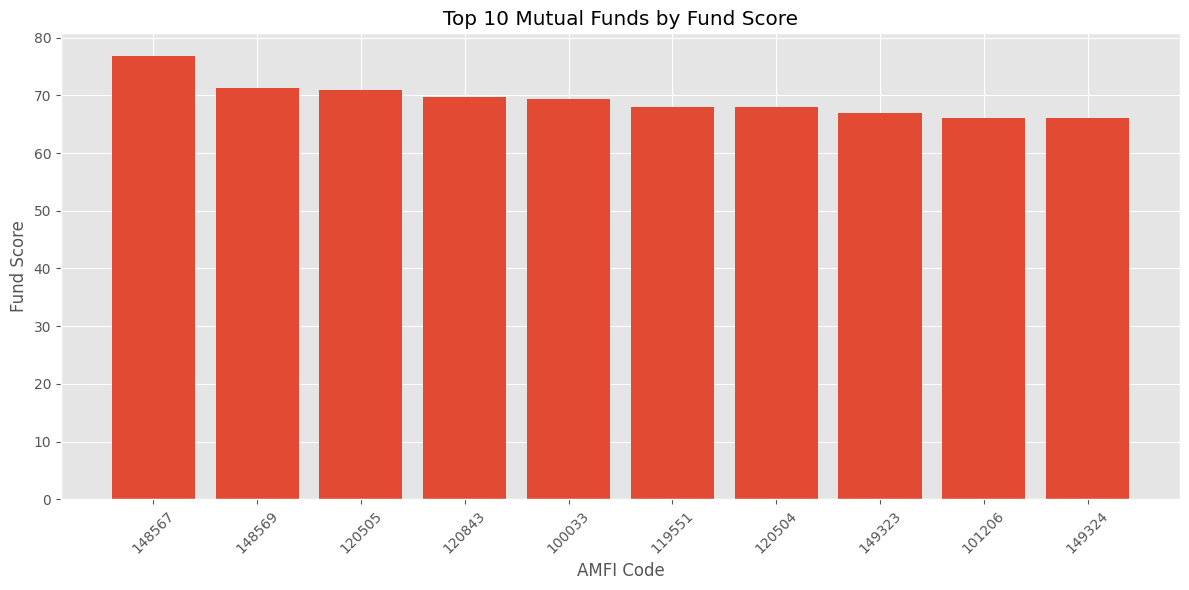

In [69]:
import matplotlib.pyplot as plt

top10 = top_funds.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['Fund_Score']
)

plt.title('Top 10 Mutual Funds by Fund Score')
plt.xlabel('AMFI Code')
plt.ylabel('Fund Score')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

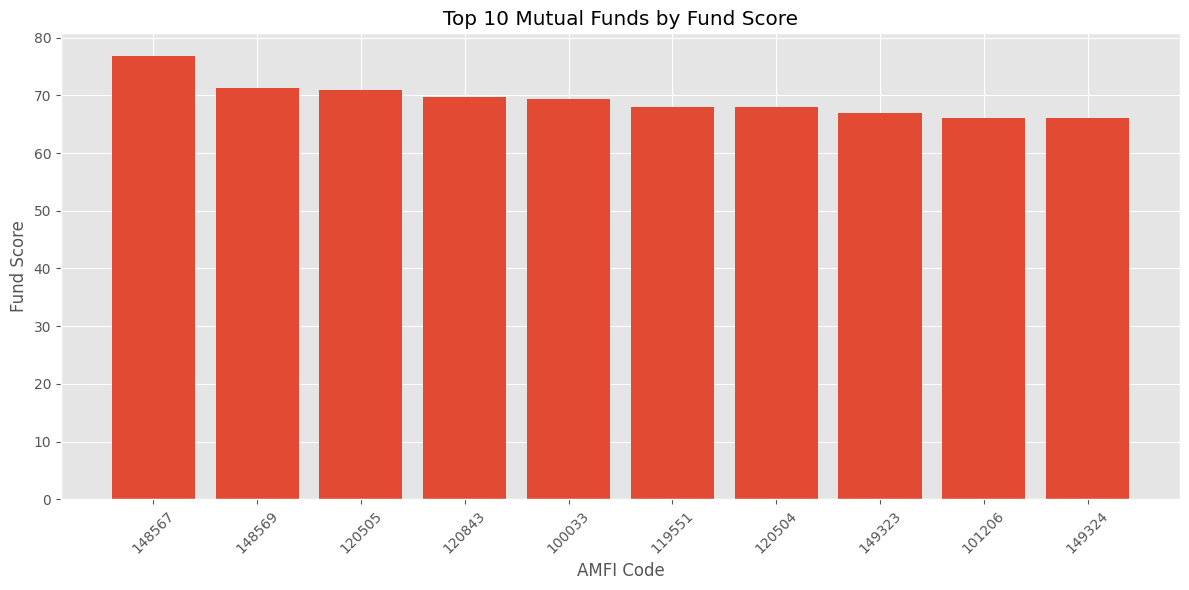

In [71]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['Fund_Score']
)

plt.title('Top 10 Mutual Funds by Fund Score')
plt.xlabel('AMFI Code')
plt.ylabel('Fund Score')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../report/top10_fund_score_chart.png',
    bbox_inches='tight'
)

plt.show()

In [73]:
benchmark_df.columns.tolist()

['date', 'index_name', 'close_value']

In [75]:
benchmark_df = benchmark_df.sort_values('date')

benchmark_df['benchmark_return'] = (
    benchmark_df['close_value']
    .pct_change()
)

In [77]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

print(nav_df['date'].dtype)
print(benchmark_df['date'].dtype)

datetime64[us]
datetime64[us]


In [78]:
benchmark_df = benchmark_df.sort_values('date')

benchmark_df['benchmark_return'] = (
    benchmark_df['close_value']
    .pct_change()
)

tracking_error_results = []

for fund in nav_df['amfi_code'].unique():

    fund_data = nav_df[
        nav_df['amfi_code'] == fund
    ].copy()

    fund_data = fund_data.sort_values('date')

    fund_data['fund_return'] = (
        fund_data['nav']
        .pct_change()
    )

    merged = pd.merge(
        fund_data[['date', 'fund_return']],
        benchmark_df[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    tracking_error = (
        (
            merged['fund_return']
            -
            merged['benchmark_return']
        ).std()
        * (252 ** 0.5)
        * 100
    )

    tracking_error_results.append({
        'amfi_code': fund,
        'Tracking_Error': tracking_error
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,8216.404517
1,100025,8216.273884
2,100033,8215.958485
3,101206,8216.234097
4,101207,8216.438015


In [79]:
benchmark_df = benchmark_df.sort_values('date')

benchmark_df['benchmark_return'] = (
    benchmark_df['close_value']
    .pct_change()
)

tracking_error_results = []

for fund in nav_df['amfi_code'].unique():

    fund_data = nav_df[
        nav_df['amfi_code'] == fund
    ].copy()

    fund_data = fund_data.sort_values('date')

    fund_data['fund_return'] = (
        fund_data['nav']
        .pct_change()
    )

    merged = pd.merge(
        fund_data[['date', 'fund_return']],
        benchmark_df[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    tracking_error = (
        (
            merged['fund_return']
            -
            merged['benchmark_return']
        ).std()
        * (252 ** 0.5)
        * 100
    )

    tracking_error_results.append({
        'amfi_code': fund,
        'Tracking_Error': tracking_error
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,8049.242113
1,100025,8049.253318
2,100033,8049.161901
3,101206,8049.227474
4,101207,8049.307408


In [82]:
tracking_error_df.to_csv(
    '../report/tracking_error.csv',
    index=False
)

tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,8049.242113
1,100025,8049.253318
2,100033,8049.161901
3,101206,8049.227474
4,101207,8049.307408


In [83]:
top5_codes = (
    scorecard_df
    .sort_values(
        'Fund_Score',
        ascending=False
    )
    .head(5)['amfi_code']
    .tolist()
)

print(top5_codes)

[148567, 148569, 120505, 120843, 100033]


In [84]:
comparison_df = nav_df[
    nav_df['amfi_code'].isin(top5_codes)
].copy()

comparison_df = comparison_df.sort_values(
    ['amfi_code', 'date']
)

comparison_df['Growth'] = (
    comparison_df.groupby('amfi_code')['nav']
    .transform(
        lambda x: (x / x.iloc[0]) * 100
    )
)

In [85]:
benchmark_df['Benchmark_Growth'] = (
    benchmark_df['close_value']
    /
    benchmark_df['close_value'].iloc[0]
) * 100

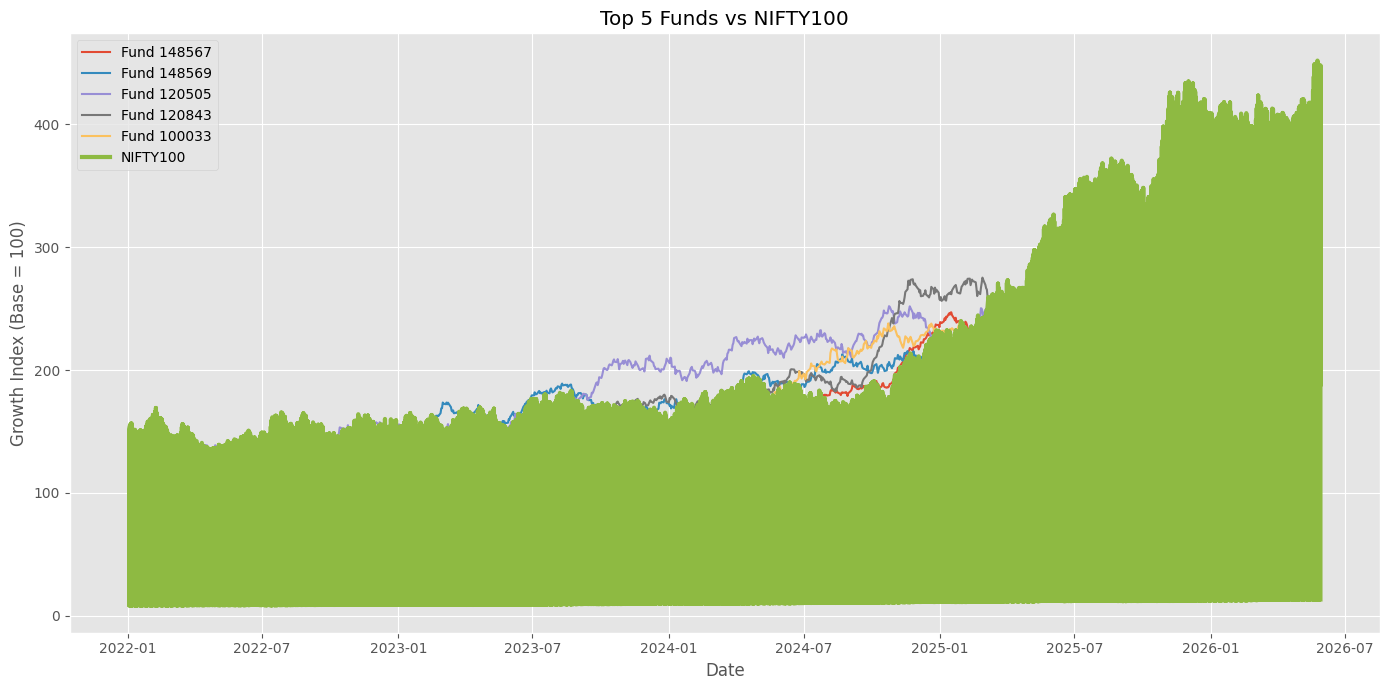

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund in top5_codes:

    temp = comparison_df[
        comparison_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['Growth'],
        label=f'Fund {fund}'
    )

plt.plot(
    benchmark_df['date'],
    benchmark_df['Benchmark_Growth'],
    linewidth=3,
    label='NIFTY100'
)

plt.title('Top 5 Funds vs NIFTY100')
plt.xlabel('Date')
plt.ylabel('Growth Index (Base = 100)')

plt.legend()

plt.tight_layout()
plt.show()

In [92]:
plt.savefig(
    '../report/benchmark_comparison_chart.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>